<a href="https://colab.research.google.com/github/Mohammed-asaad-AI/Breast-Cancer-KNN-Comparison/blob/main/Breast_Cancer_KNN_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =====  Importing Libraries =====


In [1]:
import numpy as np
import pandas as pd
import random

from collections import Counter
import warnings


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


# ===== 1. Manual KNN Function =====
I've built my own KNN Function to compare it later with KNN from Sklearn

In [2]:
def k_nearest_neighbors(data, predict, k=3):
    if k > len(data):
        warnings.warn('K is set to a value greater than total groups.')

    distances = []
    for group in data:
        for features in data[group]:
            euclidean_distance = np.linalg.norm(np.array(features) - np.array(predict))
            distances.append((euclidean_distance, group))

    votes = [label for _, label in sorted(distances)[:k]]
    vote_result = Counter(votes).most_common(1)[0][0]
    confidence = Counter(votes).most_common(1)[0][1] / k
    return vote_result, confidence

# ===== 2. Load and preprocess dataset =====



We have used data from kaggle : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

In [3]:

df = pd.read_csv('/content/Breast cancer.csv')
df.replace('?', -99999, inplace=True)
df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore', inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})    #  1 Is for Malignant ,  0 Is for Benign


In [4]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [6]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


# ===== 3. Prepare data =====


In [7]:
data = df.astype(float).values.tolist()
random.shuffle(data)

test_size = 0.2
split_index = int((1 - test_size) * len(data))
train_data_raw = data[:split_index]
test_data_raw = data[split_index:]

train_set = {0: [], 1: []}
test_set = {0: [], 1: []}

for row in train_data_raw:
    label = int(row[0])
    features = row[1:]
    train_set[label].append(features)

for row in test_data_raw:
    label = int(row[0])
    features = row[1:]
    test_set[label].append(features)

# ===== 4. Manual KNN Prediction and Accuracy =====


In [8]:
correct = 0
total = 0

for label in test_set:
    for features in test_set[label]:
        predicted, confidence = k_nearest_neighbors(train_set, features, k=5)
        if predicted == label:
            correct += 1
        total += 1

manual_knn_accuracy = correct / total

<ipython-input-2-abc4c3c6acd9>:3: UserWarning: K is set to a value greater than total groups.
  warnings.warn('K is set to a value greater than total groups.')


# ===== 5. Sklearn KNN =====


In [9]:
X = df.drop(['diagnosis'], axis=1).astype(float).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
sklearn_knn_accuracy = accuracy_score(y_test, y_pred)

# ===== 6. Results and The Comparison =====


In [10]:
print(f"\n🔎 Manual KNN Accuracy: {manual_knn_accuracy:.4f}")
print(f"⚙️  Sklearn KNN Accuracy: {sklearn_knn_accuracy:.4f}")





🔎 Manual KNN Accuracy: 0.9386
⚙️  Sklearn KNN Accuracy: 0.9561


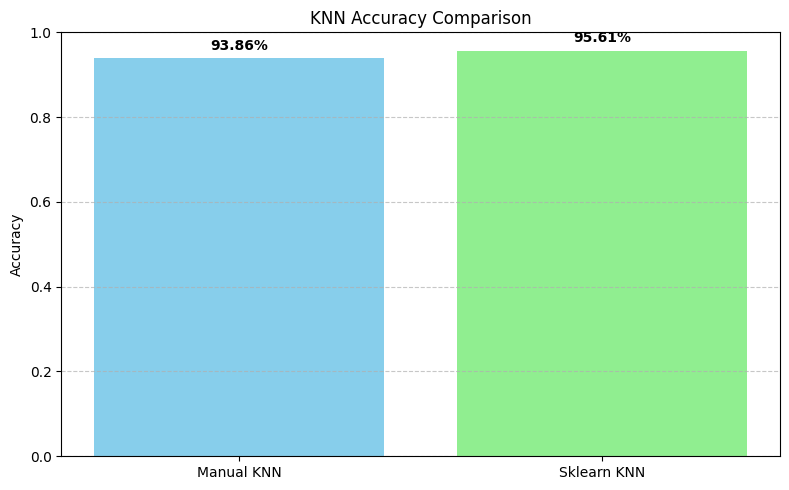

In [11]:
accuracies = [manual_knn_accuracy, sklearn_knn_accuracy]
labels = ['Manual KNN', 'Sklearn KNN']
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(8, 5))
plt.bar(labels, accuracies, color=colors)
plt.ylim(0, 1)
plt.title('KNN Accuracy Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()